# **Regression: Decision Tree Regressor (DTR)**

## **Justification of Preprocessing Strategy**

### **Scale Invariance**
Decision Tree Regressors make predictions by recursively splitting the data based on simple feature thresholds (e.g., `BMI > 30`). Because they do not calculate geometric distances between data points or rely on gradient descent optimization, they are mathematically invariant to the scale of the features. Standardization or Normalization will not change the structure of the tree or its predictions. To maintain maximum computational efficiency and preserve the direct clinical interpretability of the splitting rules, we will train the model on the **Original, Unscaled Data**.

### **The Regression Overfitting Trap**
By default, Scikit-Learn's Decision Tree Regressor allows unconstrained growth (`max_depth=None`, `min_samples_leaf=1`). In a dataset of 100,000 patients, this means the tree will grow until it creates a highly specific, fragmented leaf for nearly every individual patient in the training set. This guarantees a Training RMSE of 0.0 (perfect memorization) but terrible generalization to new patients. To build a robust model, our hyperparameter tuning will focus exclusively on structural pruning.

## **Experiment Design & Computational Efficiency**

We defined a tournament of 3 optimization levels. To explicitly monitor the model's generalization capabilities, we log **both Train and Test metrics (RMSE, MAE, R²)** simultaneously.

* **Baseline**: Executing the model with default parameters (unconstrained growth). We fully expect this run to exhibit severe overfitting, serving as a cautionary benchmark.
* **GridSearchCV**: A 5-fold cross-validated search strictly enforcing pruning boundaries. *Note: We intentionally exclude `absolute_error` as a splitting criterion because calculating the median for MAE at every node split across 80,000 rows is computationally prohibitive and inefficient compared to variance reduction (`squared_error`).*
* **Optuna Optimization**: Bayesian optimization deployed to explore the continuous parameter space of leaf sizes and tree depths, aiming to minimize the validation RMSE without widening the Train-Test performance gap.

2026/05/22 13:09:31 INFO mlflow.tracking.fluent: Experiment with name 'Regression_DecisionTree' does not exist. Creating a new experiment.
[I 2026-05-22 13:10:25,968] A new study created in memory with name: no-name-c6c49ef4-0938-40e2-ae0d-d8c44c17ce6c
[I 2026-05-22 13:10:27,517] Trial 0 finished with value: 1.7558059730928264 and parameters: {'criterion': 'squared_error', 'max_depth': 21, 'min_samples_split': 57, 'min_samples_leaf': 60}. Best is trial 0 with value: 1.7558059730928264.
[I 2026-05-22 13:10:29,084] Trial 1 finished with value: 1.67330511148391 and parameters: {'criterion': 'squared_error', 'max_depth': 12, 'min_samples_split': 75, 'min_samples_leaf': 25}. Best is trial 1 with value: 1.67330511148391.
[I 2026-05-22 13:10:30,273] Trial 2 finished with value: 1.9798694064764626 and parameters: {'criterion': 'squared_error', 'max_depth': 9, 'min_samples_split': 38, 'min_samples_leaf': 90}. Best is trial 1 with value: 1.67330511148391.
[I 2026-05-22 13:10:31,695] Trial 3 fini

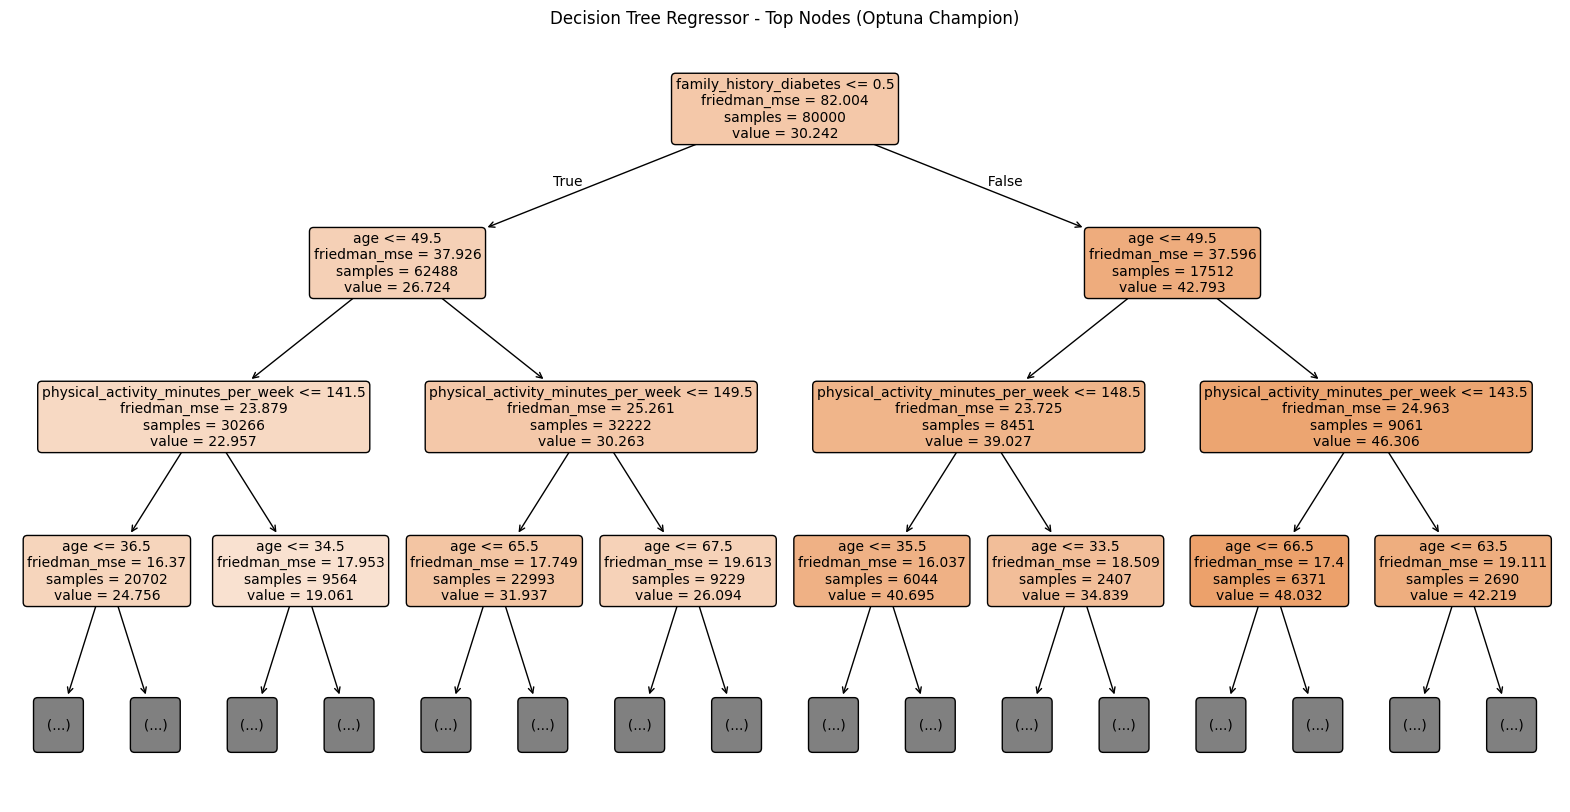

In [ ]:
import pandas as pd
import numpy as np
import time
import mlflow
import optuna
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. MLflow Configuration
mlflow.set_tracking_uri("sqlite:///C:/Users/Tiago Silva/Uni/OneDrive - Universidade Portucalense/Ambiente de Trabalho/Uni/3ano2sem/LAD/Grupo5_ProjetoLAD_Parte2/TrabalhoLAD/models/mlflow.db")
mlflow.set_experiment("Regression_DecisionTree")

# 2. Data Loading and Preparation
df = pd.read_csv("C:\\Users\\Tiago Silva\\Uni\\OneDrive - Universidade Portucalense\\Ambiente de Trabalho\\Uni\\3ano2sem\\LAD\\Grupo5_ProjetoLAD_Parte2\\TrabalhoLAD\\data\\diabetes_dataset_new_variables.csv")

categorical_cols = [
    'gender', 'ethnicity', 'smoking_status', 'education_level',
    'employment_status', 'age_groups', 'weight_status', 'income_level'
]

# Apply One-Hot Encoding
df_final = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Separate features and target 
# CRITICAL: Drop ALL classification targets to prevent data leakage!
X = df_final.drop(["diagnosed_diabetes", "diabetes_stage", "diabetes_risk_score"], axis=1)
y = df_final['diabetes_risk_score']

# Split data (80/20) - No stratify needed for continuous regression targets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

SEED = 42

def log_regression_metrics(model, X_tr, y_tr, X_te, y_te, duration):
    # Logs both Train and Test metrics to explicitly monitor the Overfitting Gap
    y_tr_pred = model.predict(X_tr)
    y_te_pred = model.predict(X_te)
    
    # Train Partition Metrics
    mlflow.log_metric("rmse_train", mean_squared_error(y_tr, y_tr_pred) ** 0.5)
    mlflow.log_metric("mae_train", mean_absolute_error(y_tr, y_tr_pred))
    mlflow.log_metric("r2_train", r2_score(y_tr, y_tr_pred))
    
    # Test Partition Metrics
    mlflow.log_metric("rmse_test", mean_squared_error(y_te, y_te_pred) ** 0.5)
    mlflow.log_metric("mae_test", mean_absolute_error(y_te, y_te_pred))
    mlflow.log_metric("r2_test", r2_score(y_te, y_te_pred))
    
    mlflow.log_metric("fit_time", duration)

# ---------------------------------------------------------
# RUN 1: BASELINE (Unconstrained Growth)
# ---------------------------------------------------------
with mlflow.start_run(run_name="DTR_Baseline"):
    reg_base = DecisionTreeRegressor(random_state=SEED)
    
    start_time = time.time()
    reg_base.fit(X_train, y_train)
    duration = time.time() - start_time
    
    mlflow.log_params(reg_base.get_params())
    mlflow.log_param("optimization", "none_default")
    
    log_regression_metrics(reg_base, X_train, y_train, X_test, y_test, duration)

# ---------------------------------------------------------
# RUN 2: GRIDSEARCHCV (Pruning Focus)
# ---------------------------------------------------------
with mlflow.start_run(run_name="DTR_GridSearch"):
    # Grid structured to force generalization and avoid memorization
    param_grid = {
        "criterion": ["squared_error", "friedman_mse"], # Dropped absolute_error due to extreme compute time on 100k rows
        "max_depth": [5, 10, 15, 20],
        "min_samples_split": [10, 20, 50],
        "min_samples_leaf": [10, 20, 50]
    }

    grid_reg = GridSearchCV(
        estimator=DecisionTreeRegressor(random_state=SEED),
        param_grid=param_grid,
        cv=KFold(n_splits=5, shuffle=True, random_state=SEED),
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    start_time = time.time()
    grid_reg.fit(X_train, y_train)
    duration = time.time() - start_time

    best_reg_grid = grid_reg.best_estimator_

    mlflow.log_params(grid_reg.best_params_)
    mlflow.log_param("optimization", "GridSearchCV")
    
    log_regression_metrics(best_reg_grid, X_train, y_train, X_test, y_test, duration)

# ---------------------------------------------------------
# RUN 3: OPTUNA (Advanced Fine-Tuning)
# ---------------------------------------------------------
def objective_reg(trial):
    params = {
        "criterion": trial.suggest_categorical("criterion", ["squared_error", "friedman_mse"]),
        "max_depth": trial.suggest_int("max_depth", 3, 25),
        "min_samples_split": trial.suggest_int("min_samples_split", 10, 100),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 5, 100),
        "random_state": SEED
    }

    model = DecisionTreeRegressor(**params)
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=KFold(n_splits=5, shuffle=True, random_state=SEED),
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )
    # Return positive RMSE for Optuna to minimize
    return -scores.mean()

with mlflow.start_run(run_name="DTR_Optuna"):
    study_reg = optuna.create_study(direction="minimize")
    
    start_time = time.time()
    study_reg.optimize(objective_reg, n_trials=30)
    duration = time.time() - start_time

    best_reg_optuna = DecisionTreeRegressor(**study_reg.best_trial.params, random_state=SEED)
    best_reg_optuna.fit(X_train, y_train)

    mlflow.log_params(study_reg.best_trial.params)
    mlflow.log_param("optimization", "optuna")
    
    log_regression_metrics(best_reg_optuna, X_train, y_train, X_test, y_test, duration)

# ---------------------------------------------------------
# VISUALIZATION: Plotting the pruned tree
# ---------------------------------------------------------
plt.figure(figsize=(20, 10))
# Plotting the Optuna champion. We limit max_depth to 3 just for visualization readability.
plot_tree(
    best_reg_optuna,
    max_depth=3,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Regressor - Top Nodes (Optuna Champion)")
plt.show()

## **Criteria Analysis: Variance Reduction (MSE vs Gini)**
While classification trees use Gini Impurity to measure node homogeneity, regression trees must use variance metrics. We explicitly tuned the `criterion` parameter, evaluating **Squared Error (MSE)** against **Friedman MSE**. 
Instead of minimizing Gini, the regressor attempts to minimize the Mean Squared Error of the target (`diabetes_risk_score`) within each child node. A split is considered optimal if it creates two new branches where the variance of the risk scores is significantly lower than the variance in the parent node. We intentionally avoided the `absolute_error` (MAE) criterion in our search grid because calculating the median at every possible split across 100,000 rows incurs an exponential computational penalty with minimal predictive gain compared to standard MSE.

## **Winner Run Selection (Priority Elimination Framework)**

### **Policy** A run is only eligible to win if it does NOT show evidence of overfitting or underfitting. Before applying the MAE/RMSE/R² decision rules, we require the Train→Test gaps to remain small enough to indicate acceptable generalization. Runs that memorize the training set or show a large Train/Test gap are disqualified regardless of metric rank.

### **Selection Criteria (priority order)**
1. **Generalization filter (mandatory):** runs with overfitting or underfitting are removed from consideration.
2. **Priority 1 (60%): Lowest MAE (Test)** — primary objective for regression accuracy.
3. **Priority 2 (30%): Lowest RMSE (Test)** — used to reject runs where RMSE grows disproportionately relative to MAE.
4. **Priority 3 (10%): Acceptable R² (Test)** — used as a quality check to confirm the model explains the target variance well enough.
5. **Tiebreaker: Lowest Fit Time** — if MAE, RMSE, and R² are effectively tied.

### **Runs Summary**

| Run | MAE (Train) | MAE (Test) | RMSE (Train) | RMSE (Test) | R² (Train) | R² (Test) | Fit Time |
|---|---:|---:|---:|---:|---:|---:|---:|
| DTR_Baseline | 0.00000 | 1.25973 | 0.00000 | 1.61087 | 1.00000 | 0.96856 | 2.54s |
| DTR_GridSearch | 0.73114 | 1.15784 | 0.94480 | 1.47032 | 0.98911 | 0.97380 | 50.68s |
| DTR_Optuna | 0.74792 | 1.16240 | 0.96604 | 1.47471 | 0.98862 | 0.97365 | 46.20s |

### **Generalization Check (Test − Train)**
- **DTR_Baseline:** MAE gap = 1.25973 − 0.00000 = **+1.25973** and RMSE gap = 1.61087 − 0.00000 = **+1.61087** → FAIL. This is clear overfitting.
- **DTR_GridSearch:** MAE gap = 1.15784 − 0.73114 = **+0.42670** and RMSE gap = 1.47032 − 0.94480 = **+0.52552** → PASS.
- **DTR_Optuna:** MAE gap = 1.16240 − 0.74792 = **+0.41448** and RMSE gap = 1.47471 − 0.96604 = **+0.50867** → PASS.

### **Step-by-Step Elimination**
**Step 1 — Apply the generalization filter**
- Passing runs: DTR_GridSearch, DTR_Optuna.
- Disqualified run: DTR_Baseline.

**Step 2 — Compare Test MAE (Priority 1 — 60%)**
- DTR_GridSearch: 1.15784
- DTR_Optuna: 1.16240
- Lowest MAE: **DTR_GridSearch**.

**Step 3 — Compare Test RMSE (Priority 2 — 30%)**
- DTR_GridSearch: 1.47032
- DTR_Optuna: 1.47471
- DTR_GridSearch remains the best choice.

**Step 4 — Check Test R² (Priority 3 — 10%)**
- DTR_GridSearch: 0.97380
- DTR_Optuna: 0.97365
- Both are excellent, but DTR_GridSearch is still slightly stronger.

### **Final Decision**
**Winner: DTR_GridSearch**

**Justification:** Among the runs that pass the generalization filter, `DTR_GridSearch` has the lowest Test MAE, the lowest Test RMSE, and the best Test R². Fit time is not needed as a tiebreaker.

## **Winner Hyperparameters**
| Parameter | Value |
|---|---|
| **criterion** | squared_error |
| **max_depth** | 20 |
| **min_samples_leaf** | 10 |
| **min_samples_split** | 10 |
| **random_state** | 42 |

## **Overfitting / Underfitting Diagnosis**
- `DTR_Baseline` is disqualified because it memorizes the training set almost perfectly (Train MAE = 0 and Train RMSE = 0), which is clear overfitting.
- `DTR_GridSearch` and `DTR_Optuna` both generalize well and are valid candidates.
- `DTR_GridSearch` is the strongest operational choice because it leads on all three regression criteria.